# Task 1 — LLM-Powered Equity Research Assistant
**CDAZZDEV Senior MLE Assessment · Financial AI**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_GITHUB_USERNAME/CDAZZDEV-MLE-YourName/blob/main/task1_financial/notebooks/Task1_Equity_Research.ipynb)

This notebook is the walkthrough for the `equity_research` package. Every step runs live, and the outputs are kept.

| Stage | Module | What it does |
|---|---|---|
| 1A data | `data.py` | ≥2y daily OHLCV from yfinance, window computed relative to today, retries, null repair |
| 1A features | `indicators.py` | SMA50/200, Wilder RSI(14), MACD(12,26,9), Bollinger(20,2), all written by hand (no TA-Lib) |
| 1A news | `news.py` | yfinance → Yahoo RSS → Google News RSS, de-duplicated, company-specific headlines first |
| 1A summary | `summary.py` | price, 52w range, P/E (with fallbacks), YTD, weighted momentum composite |
| 1B LLM | `llm.py`, `prompts.py`, `schemas.py` | OpenAI-compatible client (Groq/OpenRouter), JSON mode, Pydantic validation, logged self-repair |
| 1B reasoning | `sentiment.py`, `recommendation.py` | per-headline JSON → confidence×recency aggregate; Buy/Hold/Sell over indicator *interactions* |
| Bonus | `report.py` | one-page Markdown + styled HTML brief with an embedded matplotlib chart |

All tunable numbers are in `config.py`, and all prompt text is in `prompts.py`. API keys are read only from Colab secrets or environment variables. None are stored in the repo.

## 0. Setup
In Colab this cell clones the repo and installs dependencies. Run locally, it uses the checked-out package.

In [1]:
import os, sys, subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    REPO_URL = "https://github.com/YOUR_GITHUB_USERNAME/CDAZZDEV-MLE-YourName"
    if not Path("/content/repo").exists():
        subprocess.run(["git", "clone", "-q", REPO_URL, "/content/repo"], check=True)
    os.chdir("/content/repo/task1_financial")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # local run: notebook lives in task1_financial/notebooks
    if Path.cwd().name == "notebooks":
        os.chdir(Path.cwd().parent)

sys.path.insert(0, str(Path.cwd()))
print("Working dir:", Path.cwd())

Working dir: C:\Users\Techon Computers\Documents\Assesment\task1_financial


In [2]:
# API keys come from Colab Secrets (key icon in the sidebar) or the environment. Never hard-code them.
if IN_COLAB:
    from google.colab import userdata
    for name in ("GROQ_API_KEY", "OPENROUTER_API_KEY"):
        try:
            os.environ[name] = userdata.get(name)
        except Exception:
            pass
else:
    try:
        from dotenv import load_dotenv  # override=True: edits to .env win over stale values in the kernel
        load_dotenv(Path.cwd().parent / ".env", override=True); load_dotenv(override=True)
    except ImportError:
        pass

print({k: ("set" if os.getenv(k) else "missing") for k in ("GROQ_API_KEY", "OPENROUTER_API_KEY")})

{'GROQ_API_KEY': 'set', 'OPENROUTER_API_KEY': 'set'}


In [3]:
import json, logging
import pandas as pd
from IPython.display import HTML, Image, Markdown, display

from equity_research import config
from equity_research.pipeline import setup_logging
log_path = setup_logging()
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)

TICKER = "MSFT"
print("Log file:", log_path.relative_to(Path.cwd()))

Log file: outputs\logs\pipeline.log


---
# Task 1A — Financial Data Pipeline
## 1A.1 OHLCV fetch (≥ 2 years, no hard-coded dates)
`history_window()` computes `start = today − (2 years + 300-day warm-up)`. The warm-up means the 200-day SMA already has a value on the first day of the 2-year analysis window.

In [4]:
from equity_research.data import fetch_market_data, history_window

start, end = history_window()
print(f"Requested window: {start} -> {end} (computed relative to today)")

md_ = fetch_market_data(TICKER)
ohlcv = md_.ohlcv
span_years = (ohlcv.index[-1] - ohlcv.index[0]).days / 365.25
print(f"{md_.ticker}: {len(ohlcv)} daily bars, {ohlcv.index[0].date()} -> {ohlcv.index[-1].date()} ({span_years:.2f} years)")
print("Columns:", list(ohlcv.columns), "| nulls:", int(ohlcv.isna().sum().sum()), "| warnings:", md_.warnings)
assert span_years >= 2, "need at least two years of data"
ohlcv.tail()

Requested window: 2023-12-11 -> 2026-10-07 (computed relative to today)


23:57:26 INFO    equity_research.data: Fetched 707 daily bars for MSFT (2023-12-11 -> 2026-10-06)


MSFT: 707 daily bars, 2023-12-11 -> 2026-10-06 (2.82 years)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume'] | nulls: 0 | warnings: []


,Open,High,Low,Close,Volume
Date,,,,,
2026-09-30,511.609985,519.830017,510.309998,512.900024,27223300
2026-10-01,519.880005,522.849976,512.169983,512.799988,19731900
2026-10-02,519.390015,522.500000,513.659973,517.530029,17822300
2026-10-05,521.619995,532.349976,521.469971,525.179993,26604800
2026-10-06,531.679993,535.690002,528.780029,529.299988,21092600


## 1A.2 Technical indicators, written from first principles
| Indicator | Definition used |
|---|---|
| SMA(n) | rolling mean, `min_periods=n` (NaN until the window is full) |
| RSI(14) | **Wilder smoothing**: seeded with the simple mean of the first 14 gains/losses, then `avg = (prev·13 + x)/14` |
| MACD(12,26,9) | EMA12 − EMA26 (α = 2/(n+1), recursive); signal = EMA9 of MACD; histogram = MACD − signal |
| Bollinger(20,2) | SMA20 ± 2σ (population σ, as Bollinger defined it), plus %B and bandwidth |

In [5]:
from equity_research.indicators import add_all_indicators

frame = add_all_indicators(ohlcv)
cols = ["Close", "sma_50", "sma_200", "rsi_14", "macd", "macd_signal", "macd_hist",
        "bb_lower", "bb_middle", "bb_upper", "bb_percent_b"]
frame[cols].tail(8).round(3)

,Close,sma_50,sma_200,rsi_14,macd,macd_signal,macd_hist,bb_lower,bb_middle,bb_upper,bb_percent_b
Date,,,,,,,,,,,
2026-09-25,516.17,475.404,430.610,63.314,6.887,7.687,-0.800,486.037,500.040,514.044,1.076
2026-09-28,509.22,477.727,430.711,58.637,7.071,7.564,-0.493,486.544,499.825,513.106,0.854
2026-09-29,508.96,479.875,430.878,58.463,7.113,7.473,-0.361,486.422,499.908,513.395,0.836
2026-09-30,512.90,482.193,431.041,60.381,7.379,7.455,-0.075,485.874,500.502,515.131,0.924
2026-10-01,512.80,484.657,431.227,60.305,7.496,7.463,0.033,485.843,501.301,516.760,0.872
2026-10-02,517.53,487.391,431.456,62.701,7.879,7.546,0.333,485.073,501.672,518.271,0.978
2026-10-05,525.18,490.274,431.715,66.248,8.700,7.777,0.923,483.483,502.946,522.409,1.071
2026-10-06,529.30,493.093,431.996,68.013,9.573,8.136,1.437,482.600,504.713,526.827,1.056


### Accuracy check
1. The pytest suite compares every indicator with a separate, plain-loop reference implementation written from the textbook formula. It also covers edge cases: flat prices, only-up moves, interior NaNs, and series that are too short.
2. A second check: Wilder's RSI equals an EMA with α = 1/14 once both are seeded from the same SMA. We compute it that way with pandas and compare.

In [6]:
r = subprocess.run([sys.executable, "-m", "pytest", "-q", "--color=no", "-p", "no:cacheprovider", "tests"], capture_output=True, text=True)
print(r.stdout[-1500:])

.....................                                                    [100%]
21 passed in 3.06s



In [7]:
import numpy as np
close = frame["Close"]
delta = close.diff()
gain, loss = delta.clip(lower=0), -delta.clip(upper=0)
# seed with the SMA of the first 14 deltas, then alpha=1/14 recursion via ewm
def wilder(x):
    x = x.iloc[1:].copy()
    seed = x.iloc[:14].mean()
    x.iloc[:13] = np.nan; x.iloc[13] = seed
    return x.ewm(alpha=1/14, adjust=False, ignore_na=True).mean()
ag, al = wilder(gain), wilder(loss)
rsi_alt = 100 - 100 / (1 + ag / al)
diff = (frame["rsi_14"] - rsi_alt).abs().max()
print(f"Max |RSI(loop) - RSI(ewm alpha=1/14)| = {diff:.2e}")
sma_check = abs(frame["sma_200"].iloc[-1] - close.tail(200).mean())
print(f"SMA200 last value vs direct mean of last 200 closes: diff = {sma_check:.2e}")

Max |RSI(loop) - RSI(ewm alpha=1/14)| = 2.84e-14
SMA200 last value vs direct mean of last 200 closes: diff = 0.00e+00


## 1A.3 News headlines (≥ 10, free sources)

In [8]:
from equity_research.news import fetch_news

company = md_.info.get("longName") or TICKER
news, news_warnings = fetch_news(TICKER, company)
print(f"{len(news)} headlines | warnings: {news_warnings}")
assert len(news) >= config.MIN_HEADLINES
pd.DataFrame([{"published_at": n.published_at, "source": n.source, "publisher": n.publisher,
               "headline": n.headline} for n in news])

23:57:37 INFO    equity_research.news: Collected 15 headlines for MSFT (15 company-specific): {'yahoo_rss': 7, 'google_news_rss': 8}


15 headlines | warnings: []


,published_at,source,publisher,headline
0,2026-10-07 06:37:02+00:00,yahoo_rss,NaN,Microsoft Stock Is on Track to Trail the S&P 5...
1,2026-10-07 05:47:58+00:00,yahoo_rss,NaN,Will AI Take Your Job? Microsoft's AI Chief No...
2,2026-10-07 03:20:25+00:00,yahoo_rss,NaN,MSFT Stock Nears All-Time High: Xbox Moves To ...
3,2026-10-06 22:55:00+00:00,google_news_rss,Investor's Business Daily,"As Microsoft Adapted To AI Megatrend, Sales, P..."
4,2026-10-06 20:33:10+00:00,yahoo_rss,NaN,"Google Joins Microsoft, Amazon, and Meta on Co..."
5,2026-10-06 19:00:30+00:00,yahoo_rss,NaN,"A $1,000 Bet on Microsoft a Decade Ago Crushed..."
6,2026-10-06 18:55:39+00:00,yahoo_rss,NaN,"Dear Microsoft Stock Fans, Mark Your Calendars..."
7,2026-10-06 18:04:01+00:00,yahoo_rss,NaN,Jim Cramer: Microsoft’s “Monster” Data Center ...
8,2026-10-06 14:19:00+00:00,google_news_rss,TradingView,MSFT Rises 41% in 6 Months on Solid AI Demand:...
9,2026-10-06 14:04:00+00:00,google_news_rss,Quiver Quantitative,Microsoft Stock (MSFT) Opinions on AI Model Sh...


## 1A.4 Summary dictionary
The momentum signal is a weighted vote over six indicator components, each scored in [−1, +1]. Overbought RSI and a %B above 1 vote *against* the trend, because they signal exhaustion. If a component is missing (for example, a short history with no SMA200), its weight is spread over the components that remain.

In [9]:
from equity_research.summary import build_summary, technical_snapshot

summary = build_summary(md_.ticker, frame, md_.info)
technicals = technical_snapshot(frame)
print(json.dumps(summary, indent=2))

{
  "ticker": "MSFT",
  "company_name": "Microsoft Corporation",
  "sector": "Technology",
  "industry": "Software - Infrastructure",
  "currency": "USD",
  "as_of": "2026-10-06",
  "current_price": 529.3,
  "52_week_high": 549.2,
  "52_week_low": 348.54,
  "pct_below_52w_high": -3.62,
  "pe_ratio": 29.26,
  "pe_ratio_source": "trailing (yfinance)",
  "market_cap": 3930341244928.0,
  "ytd_return_pct": 10.14,
  "momentum_signal": {
    "label": "Strong Bullish",
    "score": 0.84,
    "components": {
      "trend_long": 1.0,
      "trend_short": 1.0,
      "ma_cross": 1.0,
      "macd": 1.0,
      "rsi": 0.901,
      "bollinger": -0.5
    }
  }
}


In [10]:
print("Relational technical snapshot passed to the LLM:")
print(json.dumps(technicals, indent=2))

Relational technical snapshot passed to the LLM:
{
  "as_of": "2026-10-06",
  "close": 529.3,
  "sma_50": 493.09,
  "sma_200": 432.0,
  "pct_vs_sma_50": 7.34,
  "pct_vs_sma_200": 22.52,
  "sma_50_vs_200_pct": 14.14,
  "last_ma_cross": "golden_cross",
  "sessions_since_ma_cross": 26,
  "rsi_14": 68.01,
  "macd": 9.573,
  "macd_signal": 8.136,
  "macd_hist": 1.437,
  "macd_hist_change_5d": 1.797,
  "bb_upper": 526.83,
  "bb_middle": 504.71,
  "bb_lower": 482.6,
  "bb_percent_b": 1.056,
  "bb_bandwidth_pct": 8.76,
  "bb_bandwidth_percentile_6m": 34.9,
  "realised_vol_20d_annualised_pct": 20.66,
  "return_5d_pct": 4.0,
  "return_20d_pct": 7.16,
  "return_60d_pct": 35.63
}


## 1A.5 Robustness: missing and invalid data
The pipeline should degrade gracefully, without unhandled exceptions.

In [11]:
from equity_research.data import DataFetchError, _clean_ohlcv

# (a) invalid ticker -> a typed, catchable error after retries
config.FETCH_MAX_RETRIES, _orig = 1, config.FETCH_MAX_RETRIES
try:
    fetch_market_data("THIS_IS_NOT_A_TICKER_123")
except DataFetchError as e:
    print("Invalid ticker handled ->", type(e).__name__, ":", str(e)[:120])
finally:
    config.FETCH_MAX_RETRIES = _orig

# (b) corrupted bars: NaN close / open / volume
dirty = ohlcv.tail(260).copy()
dirty.iloc[5, dirty.columns.get_loc("Close")] = np.nan
dirty.iloc[10, dirty.columns.get_loc("Open")] = np.nan
dirty.iloc[12, dirty.columns.get_loc("Volume")] = np.nan
cleaned, warns = _clean_ohlcv(dirty)
print("Cleaning warnings:", warns)

# (c) short history + empty fundamentals -> summary still builds, missing fields are None
short = add_all_indicators(cleaned.tail(60))
s = build_summary("TEST", short, info={})
print("Short-history summary: pe_ratio =", s["pe_ratio"], "| momentum =", s["momentum_signal"]["label"],
      "| components =", s["momentum_signal"]["components"])

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: THIS_IS_NOT_A_TICKER_123"}}}


$THIS_IS_NOT_A_TICKER_123: possibly delisted; no timezone found


23:57:38 WARNING equity_research.data: OHLCV fetch attempt 1/1 failed for THIS_IS_NOT_A_TICKER_123: No price data returned for 'THIS_IS_NOT_A_TICKER_123'.


Invalid ticker handled -> DataFetchError : Could not fetch OHLCV for 'THIS_IS_NOT_A_TICKER_123': No price data returned for 'THIS_IS_NOT_A_TICKER_123'.
Cleaning warnings: ['Dropped 1 bar(s) with missing Close.', 'Filled 1 missing Open value(s) with Close.', 'Filled 1 missing Volume value(s) with 0.']
Short-history summary: pe_ratio = None | momentum = Strong Bullish | components = {'trend_long': None, 'trend_short': 1.0, 'ma_cross': None, 'macd': 1.0, 'rsi': 0.914, 'bollinger': -0.5}


---
# Task 1B — LLM Sentiment and Signal Reasoning
## 1B.1 Prompts are kept separate from logic
All prompt text is in `equity_research/prompts.py` as constants and `string.Template`s, with distinct **system** prompts (role, rules, output contract) and **user** prompts (per-call data).

In [12]:
from equity_research import prompts
print("=== SENTIMENT_SYSTEM_PROMPT ===\n" + prompts.SENTIMENT_SYSTEM_PROMPT)
print("\n=== SENTIMENT_USER_TEMPLATE (rendered for headline #1) ===")
print(prompts.SENTIMENT_USER_TEMPLATE.substitute(company=company, ticker=TICKER,
      headline=news[0].headline, publisher=news[0].publisher))

=== SENTIMENT_SYSTEM_PROMPT ===
You are a sell-side equity research analyst who classifies the sentiment of a single
news headline with respect to the SHARE PRICE of one specific company.

Rules:
- Judge the likely short-term impact on the named company's stock, not the general tone of
  the language. "Rival X launches cheaper product" is negative for the company even though
  it is phrased positively.
- If the headline is mainly about another company, the broad market, or is a generic
  listicle / clickbait with no company-specific information, label it "neutral".
- confidence is your probability (0.0-1.0) that the label is correct. Use < 0.6 for
  ambiguous headlines, and > 0.85 only for unambiguous, material news (earnings beats/misses,
  guidance changes, regulatory actions, M&A, rating changes).
- brief_reason: one sentence, maximum 30 words, naming the specific driver.

Respond with ONLY a JSON object, no markdown, exactly this shape:
{"headline": "<headline copied verbatim>", "s

## 1B.2 Per-headline sentiment: one LLM call per headline, each validated against `HeadlineSentiment`

In [13]:
from equity_research.pipeline import make_llm_client
from equity_research.sentiment import analyse_headlines

client = make_llm_client()
print("Provider:", client.provider if client else None, "| model:", client.model if client else None)
scored, agg = analyse_headlines(client, news, TICKER, company)
per_headline = [h.model_dump(include={"headline", "sentiment", "confidence", "brief_reason"}) for h in scored]
print(json.dumps(per_headline[:3], indent=2))
pd.DataFrame([{**d, "recency_w": h.recency_weight, "fallback": h.is_fallback}
              for d, h in zip(per_headline, scored)])

23:57:39 INFO    equity_research.llm: LLM provider: groq (openai/gpt-oss-120b)


Provider: groq | model: openai/gpt-oss-120b


[
  {
    "headline": "Microsoft Stock Is on Track to Trail the S&P 500 for a 3rd Straight Year. History Says What Happened After Its Last 2 Streaks.",
    "sentiment": "negative",
    "confidence": 0.75,
    "brief_reason": "Signals continued underperformance versus the S&P 500, implying a negative short\u2011term outlook for Microsoft\u2019s share price."
  },
  {
    "headline": "Will AI Take Your Job? Microsoft's AI Chief Now Points To Nobel Laureate's Research Saying Only 5% Of Human Work Is At Risk",
    "sentiment": "neutral",
    "confidence": 0.55,
    "brief_reason": "Commentary piece without material impact on Microsoft\u2019s earnings or operations."
  },
  {
    "headline": "MSFT Stock Nears All-Time High: Xbox Moves To Secure Exclusive Rights To Stream Grand Theft Auto VI, Report Says",
    "sentiment": "positive",
    "confidence": 0.92,
    "brief_reason": "Securing exclusive GTA\u202fVI streaming rights should boost Xbox revenue and support the stock\u2019s upward traj

,headline,sentiment,confidence,brief_reason,recency_w,fallback
0,Microsoft Stock Is on Track to Trail the S&P 5...,negative,0.75,Signals continued underperformance versus the ...,0.9967,False
1,Will AI Take Your Job? Microsoft's AI Chief No...,neutral,0.55,Commentary piece without material impact on Mi...,0.9889,False
2,MSFT Stock Nears All-Time High: Xbox Moves To ...,positive,0.92,Securing exclusive GTA VI streaming rights sho...,0.9657,False
3,"As Microsoft Adapted To AI Megatrend, Sales, P...",positive,0.92,Surging sales and profits plus multiple best‑s...,0.9255,False
4,"Google Joins Microsoft, Amazon, and Meta on Co...",positive,0.75,Microsoft’s inclusion in Constellation’s energ...,0.9046,False
5,"A $1,000 Bet on Microsoft a Decade Ago Crushed...",neutral,0.78,The piece discusses historical returns and pro...,0.8913,False
6,"Dear Microsoft Stock Fans, Mark Your Calendars...",neutral,0.45,Headline offers no material information about ...,0.8906,False
7,Jim Cramer: Microsoft’s “Monster” Data Center ...,positive,0.92,Cramer highlights that Microsoft’s large data‑...,0.8832,False
8,MSFT Rises 41% in 6 Months on Solid AI Demand:...,positive,0.88,"AI demand is boosting Microsoft’s share price,...",0.8519,False
9,Microsoft Stock (MSFT) Opinions on AI Model Sh...,neutral,0.55,Vague opinion piece without clear impact on stock,0.8499,False


### Aggregation
`score = Σ pᵢ·cᵢ·rᵢ / Σ cᵢ·rᵢ`, where p ∈ {+1, 0, −1} is polarity, c is the LLM's confidence, and r = 0.5^(age/3 days) is a recency weight.
- Weighting by confidence keeps ambiguous headlines from moving the score much.
- Neutral headlines stay in the denominator, so a quiet news flow pulls the score toward 0.
- Headlines that failed validation get c = 0, so they're excluded rather than counted as fake "neutral" votes.

In [14]:
print(json.dumps(agg.model_dump(), indent=2))

{
  "score": 0.5971,
  "label": "positive",
  "n_headlines": 15,
  "n_valid": 15,
  "counts": {
    "positive": 9,
    "negative": 1,
    "neutral": 5
  },
  "mean_confidence": 0.772,
  "method": "confidence x recency (half-life 3d) weighted mean polarity"
}


## 1B.3 Buy / Hold / Sell signal reasoned over indicator *combinations*

In [15]:
from equity_research.recommendation import build_signal_prompt, generate_signal
print("=== USER PROMPT SENT TO THE LLM ===")
print(build_signal_prompt(summary, technicals, agg))

=== USER PROMPT SENT TO THE LLM ===
Ticker: MSFT (Microsoft Corporation)
As of: 2026-10-06

Technical snapshot (JSON):
{
  "as_of": "2026-10-06",
  "close": 529.3,
  "sma_50": 493.09,
  "sma_200": 432.0,
  "pct_vs_sma_50": 7.34,
  "pct_vs_sma_200": 22.52,
  "sma_50_vs_200_pct": 14.14,
  "last_ma_cross": "golden_cross",
  "sessions_since_ma_cross": 26,
  "rsi_14": 68.01,
  "macd": 9.573,
  "macd_signal": 8.136,
  "macd_hist": 1.437,
  "macd_hist_change_5d": 1.797,
  "bb_upper": 526.83,
  "bb_middle": 504.71,
  "bb_lower": 482.6,
  "bb_percent_b": 1.056,
  "bb_bandwidth_pct": 8.76,
  "bb_bandwidth_percentile_6m": 34.9,
  "realised_vol_20d_annualised_pct": 20.66,
  "return_5d_pct": 4.0,
  "return_20d_pct": 7.16,
  "return_60d_pct": 35.63
}

Rule-based momentum composite (for reference -- you may disagree with it):
{
  "label": "Strong Bullish",
  "score": 0.84,
  "components": {
    "trend_long": 1.0,
    "trend_short": 1.0,
    "ma_cross": 1.0,
    "macd": 1.0,
    "rsi": 0.901,
    "bol

In [16]:
sig = generate_signal(client, summary, technicals, agg)
print(f"Source: {sig.source} | model: {sig.model} | attempts: {sig.attempts}")
print(json.dumps(sig.signal.model_dump(), indent=2))

Source: llm | model: openai/gpt-oss-120b | attempts: 1
{
  "signal": "Buy",
  "conviction": 0.71,
  "indicator_interactions": [
    {
      "indicators": [
        "sma_200",
        "macd",
        "golden_cross"
      ],
      "interpretation": "Price is well above the 200\u2011day SMA, the 50\u2011day SMA is still above the 200\u2011day SMA and a golden cross occurred 26 sessions ago, while MACD and its histogram are positive and expanding",
      "implication": "bullish"
    },
    {
      "indicators": [
        "rsi_14",
        "bb_percent_b"
      ],
      "interpretation": "RSI is near the overbought threshold (68) and %B is above 1, meaning the price is trading above the upper Bollinger band",
      "implication": "bearish"
    },
    {
      "indicators": [
        "bb_bandwidth_percentile_6m",
        "macd_hist",
        "news_sentiment"
      ],
      "interpretation": "The Bollinger bandwidth is in the lower third of its six\u2011month range (a squeeze) and MACD histogra

## 1B.4 Structured-output validation: failures are caught, logged and repaired
Every LLM response goes through `extract_json` and then `Model.model_validate`. When validation fails:
1. the error is **logged** to `outputs/logs/pipeline.log` and stored in `client.validation_events`;
2. the exact error is sent back to the model in a **repair** turn, up to 2 retries;
3. if it still fails, the pipeline uses a deterministic fallback that's clearly labelled: zero-weight neutral for a headline, rule-based for the signal.

### Controlled test: these failures are deliberate
The live run above had no validation failures, so the failure path is tested here on purpose. `ScriptedClient` replaces **only** the network call with pre-written replies. The JSON extraction, Pydantic validation, logging, repair loop and fallback are the real production code.

| Scenario | Scripted LLM replies | Expected behaviour |
|---|---|---|
| A. Self-repair | 1) prose + JSON with `"Strong Buy"`, conviction `1.7`, missing fields → 2) valid JSON | failure logged, error fed back, **valid on attempt 2** |
| B. Never valid | `"not json"` ×3 | 3 failures logged, returns `None` after 3 attempts, **no exception** |
| C. Graceful degradation | always invalid, called through the real pipeline functions | headline → zero-weight fallback; signal → `rule_based_fallback` |

Any `validation failed` entries this cell writes to the log are **expected output**. Console logging is muted while the cell runs so the results tables stay readable. Every event is still written to `pipeline.log`, and the excerpt below shows that.

In [17]:
import contextlib
from equity_research.llm import LLMClient
from equity_research.schemas import NewsItem, TradingSignal
from equity_research.sentiment import score_headline

class ScriptedClient(LLMClient):
    """Test double: replaces only the network call; validation/repair/logging are the real code."""
    def __init__(self, replies):
        self.provider, self.model, self._last_call = "scripted", "stub", 0.0
        self.validation_events, self.n_calls, self._replies = [], 0, list(replies)
        self.disabled_reason = None
    def _chat(self, messages, temperature, max_tokens):
        self.n_calls += 1
        return self._replies.pop(0) if self._replies else "not json"

@contextlib.contextmanager
def console_logging_muted():
    """Silence console handlers only; the file handler keeps recording to pipeline.log."""
    handlers = [h for h in logging.getLogger("equity_research").handlers if type(h) is logging.StreamHandler]
    levels = [h.level for h in handlers]
    for h in handlers: h.setLevel(logging.CRITICAL + 1)
    try: yield
    finally:
        for h, lvl in zip(handlers, levels): h.setLevel(lvl)

VALID_SIGNAL = json.dumps({"signal": "Hold", "conviction": 0.6, "time_horizon": "1-3 months",
    "justification": "Trend is up. Momentum is fading. Wait for confirmation.",
    "key_risks": ["Breakdown below SMA50"],
    "indicator_interactions": [
        {"indicators": ["price", "sma_200"], "interpretation": "Primary uptrend intact", "implication": "bullish"},
        {"indicators": ["macd_hist", "rsi_14"], "interpretation": "Momentum decelerating", "implication": "neutral"}]})
INVALID_SIGNAL = 'Sure! {"signal": "Strong Buy", "conviction": 1.7, "justification": "Looks good."}'

with console_logging_muted():
    # A. invalid -> repaired
    stub_a = ScriptedClient([INVALID_SIGNAL, VALID_SIGNAL])
    res_a = stub_a.structured(task="demo_repair", system="s", user="u", schema=TradingSignal, temperature=0, max_tokens=10)
    # B. never valid -> None, no exception
    stub_b = ScriptedClient(["not json"] * 3)
    res_b = stub_b.structured(task="demo_never_valid", system="s", user="u", schema=TradingSignal, temperature=0, max_tokens=10)
    # C. graceful degradation through the real pipeline functions
    stub_c = ScriptedClient([])
    head_c = score_headline(stub_c, NewsItem(headline="Microsoft beats estimates", source="demo"), TICKER, company)
    sig_c = generate_signal(stub_c, summary, technicals, agg)

results = pd.DataFrame([
    {"scenario": "A. self-repair", "expected": "valid on attempt 2", "actual": f"{res_a.value.signal} @ {res_a.value.conviction} after {res_a.attempts} attempts",
     "failures_logged": len(stub_a.validation_events), "exception_raised": False, "pass": res_a.value is not None and res_a.attempts == 2},
    {"scenario": "B. never valid", "expected": "None after 3 attempts", "actual": f"{res_b.value} after {res_b.attempts} attempts",
     "failures_logged": len(stub_b.validation_events), "exception_raised": False, "pass": res_b.value is None and res_b.attempts == 3},
    {"scenario": "C1. headline fallback", "expected": "is_fallback, weight 0", "actual": f"is_fallback={head_c.is_fallback}, confidence={head_c.confidence}",
     "failures_logged": None, "exception_raised": False, "pass": head_c.is_fallback and head_c.confidence == 0},
    {"scenario": "C2. signal fallback", "expected": "rule_based_fallback", "actual": f"{sig_c.source} -> {sig_c.signal.signal}",
     "failures_logged": len(stub_c.validation_events), "exception_raised": False, "pass": sig_c.source == "rule_based_fallback"},
])
assert results["pass"].all(), "validation path regression"
print("All controlled-failure scenarios behaved as designed.\n")
display(results)

print("Validation events captured (scenarios A and B):")
display(pd.DataFrame([{"task": e.task, "attempt": e.attempt, "error": e.error}
                      for e in stub_a.validation_events + stub_b.validation_events]))

All controlled-failure scenarios behaved as designed.



,scenario,expected,actual,failures_logged,exception_raised,pass
0,A. self-repair,valid on attempt 2,Hold @ 0.6 after 2 attempts,1.0,False,True
1,B. never valid,None after 3 attempts,None after 3 attempts,3.0,False,True
2,C1. headline fallback,"is_fallback, weight 0","is_fallback=True, confidence=0.0",NaN,False,True
3,C2. signal fallback,rule_based_fallback,rule_based_fallback -> Buy,6.0,False,True


Validation events captured (scenarios A and B):


,task,attempt,error
0,demo_repair,1,5 schema error(s): signal: Input should be 'Bu...
1,demo_never_valid,1,invalid JSON: no JSON object found in response
2,demo_never_valid,2,invalid JSON: no JSON object found in response
3,demo_never_valid,3,invalid JSON: no JSON object found in response


In [18]:
live_failures = client.validation_events if client else []
print(f"Validation failures in the LIVE LLM run: {len(live_failures)}"
      + ("" if client else " (no LLM client configured)"))
for ev in live_failures:
    print(" -", ev.task, "attempt", ev.attempt, ":", ev.error[:200])

print(f"\nEvidence that failures are persisted -- demo entries in {log_path.name}:")
print("".join(line for line in log_path.read_text(encoding="utf-8").splitlines(keepends=True)
              if "[demo_" in line))

Validation failures in the LIVE LLM run: 0

Evidence that failures are persisted -- demo entries in pipeline.log:
23:58:14 WARNING equity_research.llm: [demo_repair] validation failed (attempt 1/3): 5 schema error(s): signal: Input should be 'Buy', 'Hold' or 'Sell' (got 'Strong buy'); conviction: Input should be less than or equal to 1 (got 1.7); indicator_interactions: Field required; justification: Value error, justification must be 3-5 sentences, got 1 (got 'Looks good.'); key_risks: Field required
23:58:14 INFO    equity_research.llm: [demo_repair] repaired on attempt 2
23:58:14 WARNING equity_research.llm: [demo_never_valid] validation failed (attempt 1/3): invalid JSON: no JSON object found in response
23:58:14 WARNING equity_research.llm: [demo_never_valid] validation failed (attempt 2/3): invalid JSON: no JSON object found in response
23:58:14 WARNING equity_research.llm: [demo_never_valid] validation failed (attempt 3/3): invalid JSON: no JSON object found in response
23:58:14

---
# Bonus — One-page Equity Research Brief
Combines 1A and 1B into Markdown and styled HTML (with the chart embedded as base64), and saves the full analysis JSON.

    chart: outputs\MSFT_2026-10-06_chart.png
 markdown: outputs\MSFT_2026-10-06_brief.md
     html: outputs\MSFT_2026-10-06_brief.html
     json: outputs\MSFT_2026-10-06_analysis.json


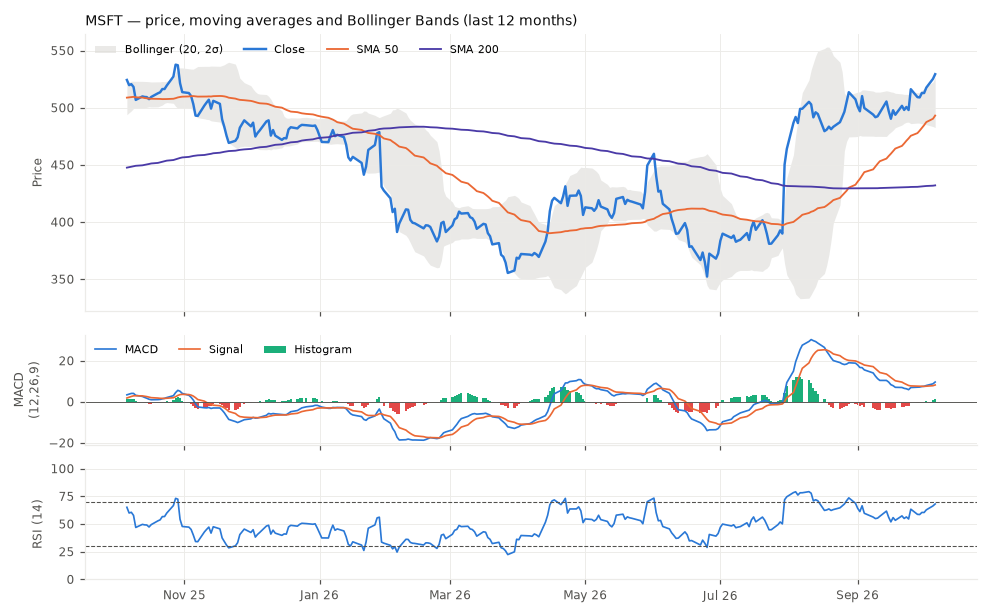

In [19]:
from equity_research.pipeline import Task1AResult, Task1BResult, write_outputs

a = Task1AResult(md_.ticker, frame, summary, technicals, news, md_.warnings + news_warnings)
b = Task1BResult(scored, agg, sig, client.provider if client else None,
                 client.n_calls if client else 0, list(client.validation_events) if client else [])
paths = write_outputs(a, b)
for k, p in paths.items():
    print(f"{k:>9}: {p.relative_to(Path.cwd())}")
display(Image(filename=str(paths["chart"])))

In [20]:
display(Markdown(paths['markdown'].read_text(encoding='utf-8').replace(f"![Technical chart]({paths['chart'].name})", '*(chart shown above)*')))

# Equity Research Brief — Microsoft Corporation (MSFT)
*As of 2026-10-06 · Generated by the CDAZZDEV Task 1 pipeline*

## Company Snapshot
| Metric | Value |
|---|---|
| Sector / Industry | Technology / Software - Infrastructure |
| Current price | 529.30 USD |
| 52-week range | 348.54 – 549.20 (-3.6% from high) |
| P/E ratio | 29.26 (trailing (yfinance)) |
| Market cap | 3.93T USD |
| YTD return | +10.14% |

## Technical Outlook
*(chart shown above)*

- Trend: price +7.34% vs SMA50, +22.52% vs SMA200 (golden cross 26 sessions ago).
- Momentum: RSI(14) 68.0; MACD 9.57 vs signal 8.14, histogram +1.44 (5-day change +1.80).
- Volatility: Bollinger %B 1.06, bandwidth 8.8% (35th pct of 6m); 20d realised vol 20.7% annualised.
- Rule-based momentum composite: **Strong Bullish** (score +0.84).

## News Sentiment Summary
Overall sentiment **positive** (score +0.60 on −1..+1) across 15 headlines — 9 positive, 5 neutral, 1 negative; mean confidence 0.77.

**Top headlines**

1. **[POSITIVE · 0.92]** MSFT Stock Nears All-Time High: Xbox Moves To Secure Exclusive Rights To Stream Grand Theft Auto VI, Report Says *(unknown)* — Securing exclusive GTA VI streaming rights should boost Xbox revenue and support the stock’s upward trajectory.
2. **[POSITIVE · 0.92]** As Microsoft Adapted To AI Megatrend, Sales, Profits Surged. MSFT Leads 9 Joining IBD Best Stock Lists *(Investor's Business Daily)* — Surging sales and profits plus multiple best‑stock list inclusions signal strong performance, likely boosting the share price.
3. **[POSITIVE · 0.92]** Jim Cramer: Microsoft’s “Monster” Data Center Play Is Starting to Pay Off *(unknown)* — Cramer highlights that Microsoft’s large data‑center investments are beginning to generate returns, suggesting revenue growth.

## Recommendation: **BUY** (conviction 71%)
The long‑term trend remains robust, with price far above both the 50‑day and 200‑day moving averages and a recent golden cross confirming bullish momentum. MACD momentum is still accelerating, and a low Bollinger bandwidth percentile suggests a potential breakout, which is reinforced by upbeat news sentiment. However, RSI is approaching overbought levels and the price sits above the upper Bollinger band, indicating short‑term exhaustion risk. The bullish forces outweigh the bearish warning signs, supporting a modest upside expectation over the next 1‑3 months. Consequently, a Buy recommendation with moderate conviction is appropriate.

**Indicator interactions considered**

- *sma_200 + macd + golden_cross* → bullish: Price is well above the 200‑day SMA, the 50‑day SMA is still above the 200‑day SMA and a golden cross occurred 26 sessions ago, while MACD and its histogram are positive and expanding
- *rsi_14 + bb_percent_b* → bearish: RSI is near the overbought threshold (68) and %B is above 1, meaning the price is trading above the upper Bollinger band
- *bb_bandwidth_percentile_6m + macd_hist + news_sentiment* → bullish: The Bollinger bandwidth is in the lower third of its six‑month range (a squeeze) and MACD histogram is rising, while news sentiment is strongly positive (+0.60)

**Key risks to the call:** RSI approaching overbought territory could trigger a pull‑back; Price above the upper Bollinger band may reverse if momentum stalls; Unexpected macro‑economic or sector‑specific headwinds could dampen tech demand

*Signal source: llm (openai/gpt-oss-120b); horizon 1-3 months.*

## Risk Disclaimer
> This report was generated automatically by a machine-learning pipeline for educational and assessment purposes only. It is not investment advice, an offer, or a solicitation to buy or sell any security. Technical indicators are backward-looking, LLM output can be wrong or incomplete, and news sentiment is inferred from headlines only. Past performance does not guarantee future results. Consult a licensed financial adviser before making any investment decision.



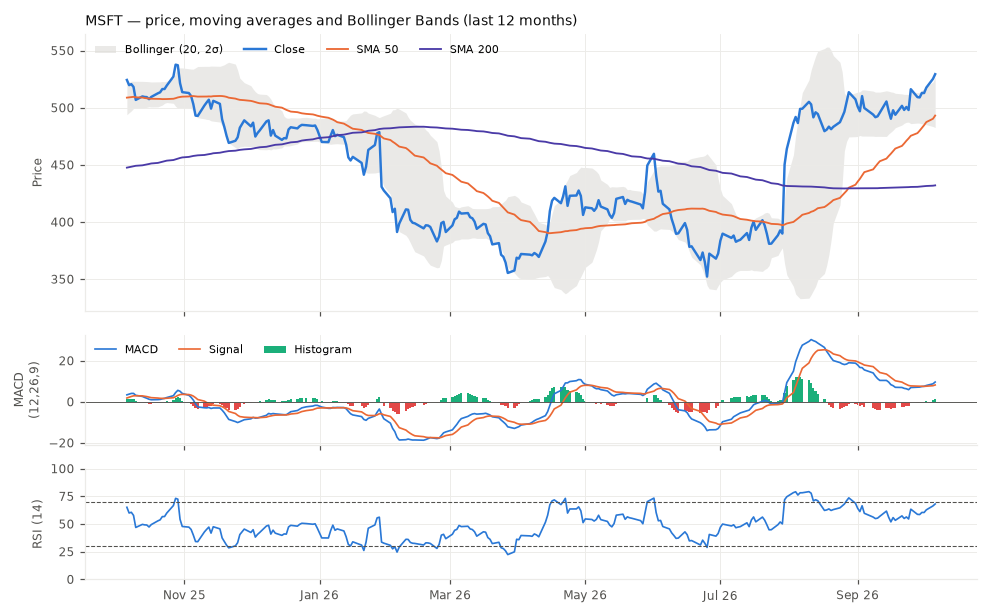

In [21]:
display(HTML(paths['html'].read_text(encoding='utf-8')))

---
## Appendix — signal system prompt (full text)

In [22]:
print(prompts.SIGNAL_SYSTEM_PROMPT)

You are a senior technical analyst writing the first-pass recommendation for an equity
research brief. You receive pre-computed technical indicators, derived relational features
and an aggregated news-sentiment score. Produce a Buy, Hold or Sell signal for a
1-3 month horizon.

How to reason (this is what you are evaluated on):
1. Reason over COMBINATIONS of indicators, never one in isolation. Examples of the kind of
   analysis expected:
   - Trend vs momentum: price above a rising 200-day SMA but a MACD histogram that is
     shrinking -> uptrend intact but losing momentum.
   - Momentum vs exhaustion: RSI near 70 while %B > 1 -> strong but stretched; elevated
     pull-back risk.
   - Volatility regime: a low Bollinger bandwidth percentile (squeeze) means a large move is
     likely; the MACD direction hints at which way.
   - Confirmation vs divergence: news sentiment that agrees with the technical picture
     raises conviction; disagreement lowers it.
2. Identify where indicators